<a href="https://colab.research.google.com/github/tetianaboyko3/Comprehensive-Analysis-of-Consumer-Behavior-and-Sales-Drivers-in-E-commerce/blob/main/Final_Project_Tetiana_Boiko_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Comprehensive Analysis of Consumer Behavior and Sales Drivers in E-commerce**

#📦 Опис даних

Набір даних містить інформацію про покупки клієнтів інтернет-магазину, включаючи демографічні характеристики клієнтів, деталі покупок, способи оплати, доставку та рівень задоволеності.

**Опис колонок:**
- `Customer ID` - Унікальний ідентифікатор клієнта
- `Age` - Вік клієнта
- `Gender` - Стать клієнта
- `Item Purchased` - Назва товару
- `Category` - Категорія товару
- `Purchase Amount (USD)` - Сума покупки в доларах США
- `Location` - Локація клієнта
- `Size` - Розмір товару
- `Color` - Колір товару
- `Season` - Сезон покупки
- `Review Rating` - Рейтинг від клієнта (1–5)
- `Subscription Status` - Наявність підписки
- `Payment Method` - Спосіб оплати
- `Shipping Type` - Тип доставки
- `Discount Applied` - Чи застосована знижка
- `Promo Code Used` - Чи використано промокод
- `Previous Purchases` - Кількість попередніх покупок
- `Preferred Payment Method` - Улюблений спосіб оплати
- `Frequency of Purchases` - Частота покупок


# ⚙️ Завантаження бібліотек та набору даних

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

In [ ]:
# Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/shopping_trends.csv')

In [ ]:
print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])

Кількість рядків: 3900
Кількість колонок: 19


In [ ]:
# Огляд набору даних
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [ ]:
# Оцінюємо структуру датасету
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

# 🧹 Перевірка та очищення даних

In [ ]:
# Перевірка на порожні значення
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


- Датасет є ідеально "чистим" з точки зору пропущених значень

In [ ]:
# Перевірка на дублікати
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Age Group


- У датасеті повністю відсутні ідентичні рядки-дублікати. Дані унікальні, що свідчить про високу якість вибірки та дозволяє продовжувати аналіз без ризику викривлення статистики повторами

In [ ]:
# Отримання статистичного огляду категоріальних ознак
df.describe(include="O")

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,696,675,2223,2223,677,584


**💡 Висновки з отриманої таблиці:**

- Повнота даних:

У всіх 19 колонках показник count дорівнює 3900. Це підтверджує, що в датасеті немає пропущених значень (NaN), і дані готові до подальшого аналізу без додаткового заповнення.
- Валідність категорій:

Кількість унікальних значень (unique) відповідає логіці: статі — 2, сезони — 4, категорії — 4. Це свідчить про те, що в даних немає дублікатів через помилки в написанні).
Велика кількість локацій (50) та категорій товарів (25) забезпечує достатню варіативність для сегментації.

*💎 Первинні бізнес-інсайти:*

Найбільш активний сегмент — чоловіки (Male, 2652 транзакції).
Найпопулярніша категорія — Одяг (Clothing), а товар-лідер — Блуза (Blouse).
Більшість клієнтів купують без підписки та без використання промокодів (значення No є найбільш частотними).

✅  *Статус:*

 Дані перевірені, аномалій не виявлено. Можна переходити до розрахунку бізнес-метрик.


In [ ]:
# Змінимо відображення кількості цифр після коми до 2 та розглянемо статистичні показники даних
df.drop(columns=['Customer ID']).describe().round(2)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3900.00
mean,44.07,59.76,3.75,25.35
std,15.21,23.69,0.72,14.45
min,18.00,20.00,2.50,1.00
25%,31.00,39.00,3.10,13.00
50%,44.00,60.00,3.70,25.00
75%,57.00,81.00,4.40,38.00
max,70.00,100.00,5.00,50.00


**💡 На основі отриманих статистичних показників робимо висновок:**

- 📅 Вік клієнтів: середній вік покупця становить приблизно 44 роки. Аудиторія досить різноманітна — від молоді (18 років) до людей похилого віку (70 років).

- 💰  Фінансові показники: середній чек покупки складає \$59.76.
При цьому   спостерігається широка варіативність : мінімальна покупка коштує \$20, а  максимальна - \$100.

- 🤝 Лояльність: клієнти є доволі досвідченими користувачами сервісу — у середньому кожен з них уже здійснив понад 25 попередніх покупок.

- ⭐ Задоволеність: середній рейтинг товарів становить 3.75 з 5.0. Це непоганий показник, проте він далекий від ідеального, що вказує на наявність потенціалу для покращення якості сервісу або товарів.

# 📊 Business-Driver Analysis

###**1. 💼 Business Overview**

In [ ]:
# Total Revenue
total_revenue = df['Purchase Amount (USD)'].sum()

# Average Order Value (AOV)
aov = df['Purchase Amount (USD)'].mean()

# Average Rating
avg_rating = df['Review Rating'].mean()

profit_margin = 0.3
total_profit = total_revenue * profit_margin

In [ ]:
print("=== 📋 BUSINESS OVERVIEW ===")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value (AOV): ${aov:,.2f}")
print(f"Average Rating: {avg_rating:.2f} / 5")
print(f"Estimated Profit (30% margin): ${total_profit:,.2f}")

=== 📋 BUSINESS OVERVIEW ===
Total Revenue: $233,081.00
Average Order Value (AOV): $59.76
Average Rating: 3.75 / 5
Estimated Profit (30% margin): $69,924.30


In [ ]:
# Кількість замовлень
total_orders = df.shape[0]

# Середня кількість покупок на клієнта
avg_purchases_per_customer = df.groupby('Customer ID')['Previous Purchases'].mean().mean()

# Частка замовлень зі знижкою
discount_rate = df['Discount Applied'].value_counts(normalize=True).get('Yes', 0)

print(f"Total Orders: {total_orders}")
print(f"Avg Purchases per Customer: {avg_purchases_per_customer:.2f}")
print(f"Discount Usage Rate: {discount_rate:.2%}")

Total Orders: 3900
Avg Purchases per Customer: 25.35
Discount Usage Rate: 43.00%


💡 **На основі отриманих даних можна зробити наступні висновки щодо поточної діяльності:**

🔹 **Стабільна прибутковість**: загальний дохід складає 233,081 \$, а оціночний прибуток (при маржі 30%) — майже 70,000 \$. Це свідчить про здорову фінансову основу.

🔹 **Лояльність клієнтів:** показник у 25.35 покупок на клієнта є надзвичайно високим. Це вказує на те, що клієнти задоволені продуктом і повертаються знову.

🔹 **Залежність від знижок:** 43% замовлень здійснюються з використанням дисконту. Це досить високий показник, який може свідчити про те, що клієнти звикли чекати на акції перед покупкою.

🔹 **Середній чек (AOV)** cкладає  $59,76. Це база для подальшого зростання доходів.

🔹 **Задоволеність**: оцінка 3.75 з 5 є непоганою, але залишає значний простір для покращення сервісу або якості товарів.

###**2. 💰 Структура доходів та ключові драйвери виручки за товарною номенклатурою.**

In [ ]:
# Групуємо по Item Purchased і рахуємо total revenue
item = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().reset_index()

item

,Item Purchased,Purchase Amount (USD)
0,Backpack,8636
1,Belt,9635
2,Blouse,10410
3,Boots,9018
4,Coat,9275
5,Dress,10320
6,Gloves,8477
7,Handbag,8857
8,Hat,9375
9,Hoodie,8767


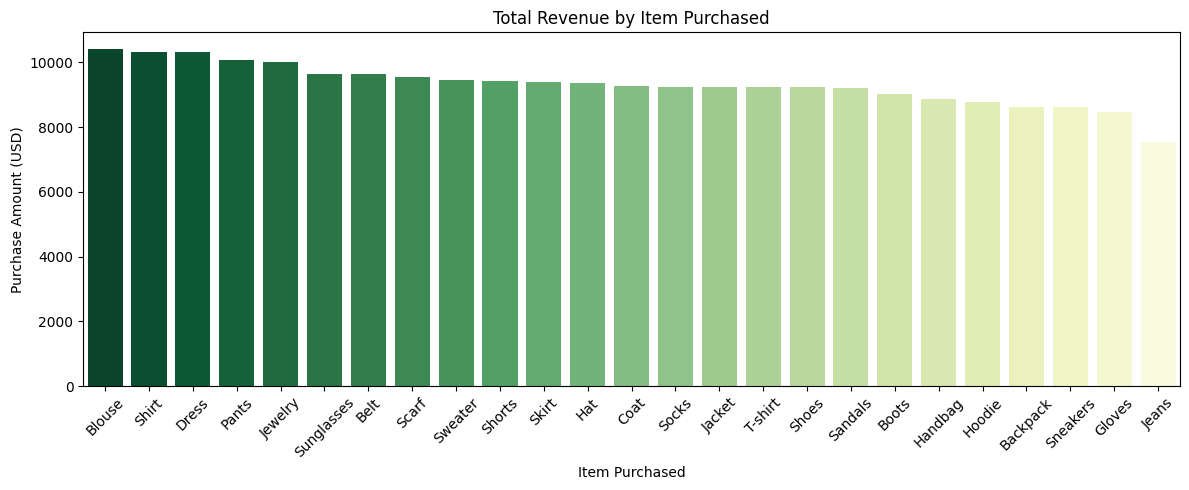

In [ ]:
# Сортуємо дані за спаданням виручки
item = item.sort_values(by='Purchase Amount (USD)', ascending=False)


# Візуалізація розподілу загального доходу за кожним видом товару
plt.figure(figsize=(12, 5))

sns.barplot(
    data=item,
    x='Item Purchased',
    y='Purchase Amount (USD)',
    hue='Item Purchased',
    palette='YlGn_r',
    legend=False
)

plt.title('Total Revenue by Item Purchased')
plt.ylabel('Purchase Amount (USD)')
plt.xlabel('Item Purchased')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**💡 Висновки:**

 🏆  Топ-категорії:

Найбільшу виручку (понад **10,000 USD**) приносять Blouse, Shirt та Dress. Це базовий асортимент, який формує основний грошовий потік.

📉 Аутсайдери:

 Найменший внесок у дохід має  Jeans, проте навіть цей товар демонструє стабільні показники (близько 8,000 USD).

**🎯 Рекомендації:**

З огляду на невеликий розрив між лідерами та аутсайдерами, варто зосередитися на маржинальності кожного товару, оскільки обсяги продажів у них подібні.

###**3. 🗺️ Регіональна ефективність: виручка, середній чек та охоплення**

In [ ]:
# Аналіз доходу та кількості клієнтів за локацією
revenue_by_location = df.groupby('Location').agg(
    total_revenue=('Purchase Amount (USD)', 'sum'),      # загальний дохід
    avg_revenue=('Purchase Amount (USD)', 'mean'),       # середній чек
    number_of_customers=('Customer ID', 'nunique')       # кількість унікальних клієнтів
).sort_values('total_revenue', ascending=False).round(2)

revenue_by_location

,total_revenue,avg_revenue,number_of_customers
Location,,,
Montana,5784,60.25,96
Illinois,5617,61.05,92
California,5605,59.00,95
Idaho,5587,60.08,93
Nevada,5514,63.38,87
Alabama,5261,59.11,89
New York,5257,60.43,87
North Dakota,5220,62.89,83
West Virginia,5174,63.88,81


In [ ]:
# Побудова інтерактивної карти
us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC"
}


state_data = df.groupby('Location').agg(
    total_revenue=('Purchase Amount (USD)', 'sum'),
    avg_revenue=('Purchase Amount (USD)', 'mean'),
    number_of_customers=('Customer ID', 'nunique') # или 'count', если считаем транзакции
).reset_index()


state_data['state_code'] = state_data['Location'].str.strip().map(us_state_to_abbrev)
state_data = state_data.dropna(subset=['state_code'])


fig = px.choropleth(
    data_frame=state_data,
    locations='state_code',
    locationmode="USA-states",
    color='total_revenue',
    hover_name='Location',

    hover_data={
        'state_code': False,
        'total_revenue': ':,.1f',
        'avg_revenue': ':,.2f',
        'number_of_customers': True
    },
    scope="usa",
    color_continuous_scale="Tropic",
    title="🗺️ Аналіз ефективності продажів по штатах США "
)

fig.show()


**💡 Висновки:**

- 🏆 Найвищу виручку генерують штати Монтана ($5,784)  та  Каліфорнія (\$5,605). Це свідчить про високу затребуваність продукту як у густонаселених штатах, так і в регіонах з потенційно вищим середнім чеком.

- 📉 Критичні зони (Антитоп): найнижчі показники зафіксовано в Канзасі (\$3,430) та Флориді (\$3,760). Розрив між лідером та аутсайдером становить майже 70%, що вказує на нерівномірне покриття ринку.

- 📍 Географічна аномалія: Флорида, попри велику кількість населення, показує низьку ефективність, що може бути пов’язано з невдалою логістикою або високою конкуренцією в регіоні.

**🎯 Рекомендації:**

- 🚀  Масштабування успіху: проаналізувати причини лідерства в Монтані (маркетингові канали, асортимент) та застосувати ці практики в сусідніх штатах (Вайомінг, Дакота).

- 🩺 Реанімація Флориди: провести аудит маркетингових витрат у Флориді. Якщо охоплення високе, а дохід низький — переглянути цінову політику або актуальність асортименту для цього клімату ☀️.

- 🏗️ Оптимізація логістики: розглянути можливість створення регіональних хабів у штатах-лідерах (наприклад, у Каліфорнії) для зниження витрат на доставку та покращення клієнтського досвіду.

###**4. 📈 Структура продажів за сезонами: обсяги та прибутковість**


In [ ]:
#  Рахуємо основні метрики по сезонах
seasonal_analysis = df.groupby('Season')['Purchase Amount (USD)'].agg([
    ('total_sales', 'sum'),
    ('order_count', 'count'),
    ('avg_check', 'mean')
]).reset_index()

seasonal_analysis = seasonal_analysis.sort_values('total_sales', ascending=False)


print("Аналіз сезонності продажів:")
print(seasonal_analysis)

total_revenue = seasonal_analysis['total_sales'].sum()
seasonal_analysis['revenue_percentage'] = (seasonal_analysis['total_sales'] / total_revenue * 100).round(2)

print("\nЧастка продажів по сезонах (%):")
print(seasonal_analysis[['Season', 'revenue_percentage']])

Аналіз сезонності продажів:
   Season  total_sales  order_count  avg_check
0    Fall        60018          975  61.556923
1  Spring        58679          999  58.737738
3  Winter        58607          971  60.357364
2  Summer        55777          955  58.405236

Частка продажів по сезонах (%):
   Season  revenue_percentage
0    Fall               25.75
1  Spring               25.18
3  Winter               25.14
2  Summer               23.93


**💡 Висновки:**
- 🍂 Лідер сезону — Осінь (Fall):
Це найбільш прибутковий період **(60,018\$** або **25.75%** доходу).
Восени зафіксовано найвищий середній чек (\$61.56). Клієнти купують або дорожчі товари, або більше речей за один раз.

- 🌱  Найбільша активність — Весна (Spring):
Хоча дохід трохи менший, ніж восени, весна має найбільшу кількість замовлень (999). Це сезон масових покупок, але з меншим середнім чеком (\$58.74).
- ☀️ Аутсайдер — Літо (Summer):
Літо приносить найменше доходу (23.93%). Тут і найменша кількість замовлень (955), і найнижчий середній чек (\$58.41).

**🎯 Рекомендації:**
- 🍂 Восени (Fall): Оскільки середній чек тут найвищий, варто зосередитися на продажах преміальних або комплексних товарів. Це найкращий час для максимізації прибутку.

- 🌱 Навесні (Spring): Оскільки кількість замовлень рекордна, використовуйте цей період для залучення нових клієнтів. Навіть невеликі знижки можуть значно збільшити обсяг продажів через високу активність аудиторії.

- ☀️ Влітку (Summer): Потрібні маркетингові заходи для стимулювання продажів (наприклад, сезонні розпродажі або акції "1+1=3"), щоб підняти показники до рівня інших сезонів.

###**5. 💎 Аналіз доходу за сегментами: стать, вік та статус підписки**

In [ ]:
# Аналіз доходу(revenue) за статтю клієнтів
revenue_by_gender = df.groupby('Gender')['Purchase Amount (USD)'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    number_of_purchases='count'
).sort_values('total_revenue', ascending=False).round(2)

revenue_by_gender

,total_revenue,avg_revenue,number_of_purchases
Gender,,,
Male,157890,59.54,2652
Female,75191,60.25,1248


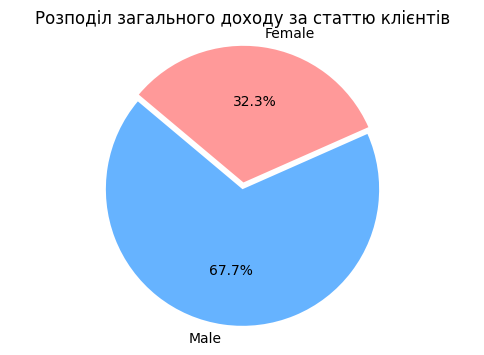

In [ ]:
# Візуалізація доходу(revenue) за статтю клієнтів
plt.figure(figsize=(6, 4))
colors = ['#66b3ff', '#ff9999']

# Побудова кругової діаграми
plt.pie(
    revenue_by_gender['total_revenue'],
    labels=revenue_by_gender.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0)
)

plt.title('Розподіл загального доходу за статтю клієнтів')
plt.axis('equal')
plt.show()

**💡 Висновки:**
- Загальний дохід (total_revenue): Чоловіки 🧔 принесли значно **більше** доходу — 157,890 USD, тоді як жінки — 75,191 USD.

- Кількість покупок (number_of_purchases): Кількість транзакцій серед чоловіків (2,652) більш ніж удвічі перевищує кількість покупок серед жінок  👩 (1,248).

- Середній чек (avg_revenue): Незважаючи на менший загальний дохід, жінки в середньому витрачають трохи більше за одну покупку — 60.25 USD проти 59.54 USD у чоловіків.

 **🎯 Рекомендації:**

- Масштабуйте жіночу аудиторію 👗: оскільки жінки мають вищий середній чек, вони є якіснішим сегментом. Навіть невелике залучення нових покупчинь або підвищення частоти їхніх покупок дасть суттєвий приріст доходу.
- Утримуйте чоловіків через лояльність  👔 : чоловіки забезпечують основний об'єм (LTV). Сфокусуйтеся на програмах лояльності або крос-продажах, щоб ще більше збільшити їхню частоту покупок, поки охоплення жіночого сегмента зростає.

In [ ]:
# Створюємо вікові групи (Age Group)
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [ ]:
# Аналіз доходу(revenue) за віковими групами клієнтів
revenue_by_age = df.groupby('Age Group', observed=False)['Purchase Amount (USD)'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    number_of_purchases='count'
).sort_values('total_revenue', ascending=False).round(2)

revenue_by_age

,total_revenue,avg_revenue,number_of_purchases
Age Group,,,
56-70,65256,59.06,1105
46-55,45619,60.58,753
26-35,44342,59.76,742
36-45,43234,59.31,729
18-25,30491,60.74,502


In [ ]:
# Створення кругової діаграми

fig = px.pie(
    revenue_by_age,
    values='total_revenue',
    names=revenue_by_age.index,
    title='Розподіл загального доходу за віковими групами (%)',
    hole=0.5,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    pull=[0.05] * len(revenue_by_age)
)

fig.update_layout(
    width=500,
    height=500,
    title_x=0.5
)

fig.show()

**💡 Висновки:**
- Найприбутковіша група 💎: клієнти віком **56–70** років (28.5%). Вони принесли **найбільший** загальний дохід (**65,256 USD**) та здійснили найбільшу кількість покупок (1,105).

- Найвищий середній чек 💳: Група **18–25** років має найвищий показник avg_revenue — **60.74 USD**, хоча ця ж група принесла найменше загального доходу.

- Стабільність витрат ⚖️: Середній чек (avg_revenue) в усіх вікових категоріях дуже подібний і коливається в межах 59.06 – 60.74 USD.

**🎯 Рекомендації:**

- 👔 Зміцнюйте лояльність групи 56–70: це  "ядро", яке забезпечує 28.5% доходу. Оскільки вони купують найчастіше, сфокусуйтеся на програмах утримання, реферальних бонусах або спеціальних пропозиціях для постійних клієнтів цього віку.
- 🚀 Стимулюйте активність молоді (18–25): ця група готова витрачати більше за один раз (найвищий середній чек), але купує рідко. Спробуйте залучити їх через таргетовану рекламу або акції "купуй більше — плати менше", щоб збільшити кількість їхніх транзакцій.
- 🖇️ Уніфікуйте пропозиції середнього чека: оскільки витрати в усіх групах стабільні (близько 60 USD), ви можете впроваджувати єдині механіки допродажів (upsell) для всіх категорій, оскільки купівельна спроможність за одну покупку у них майже однакова.


In [ ]:
# Аналіз доходу(revenue) за статусом підписки клієнта
revenue_by_subscription = df.groupby('Subscription Status')['Purchase Amount (USD)'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    number_of_purchases='count'
).sort_values('total_revenue', ascending=False).round(2)

revenue_by_subscription

,total_revenue,avg_revenue,number_of_purchases
Subscription Status,,,
No,170436,59.87,2847
Yes,62645,59.49,1053


**💡 Висновки:**

Аналіз показав, що клієнти **без підписки** генерують **більший** загальний дохід, ніж **підписники**.

In [ ]:
# Сегментація доходу за статусом підписки, статтю та віком
segment_revenue = df.groupby(
    ['Subscription Status', 'Gender', 'Age Group'], observed=False
)['Purchase Amount (USD)'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    number_of_purchases='count'
).sort_values('total_revenue', ascending=False).round(2)

segment_revenue.head(10)

# Застосовуємо стилізацію до топ-10 результатів
styled_segment = segment_revenue.head(10).style.background_gradient(
    cmap='YlGn',           # Колірна схема (Yellow-Green). Також спробуйте 'Viridis' або 'Blues'
    subset=['total_revenue', 'avg_revenue'] # Стовпці, до яких застосувати градієнт
)
styled_segment

**💡 Висновки:**

 Найбільший дохід (**27,903** USD) приносять **чоловіки** 🧔 віком **56–70 років**, які **не мають підписки**. Ця група також здійснила найбільшу кількість покупок (**475**).

###**6. 😊 Аналіз задоволеності клієнтів**

In [ ]:
# Аналіз рейтингу за сегментами
rating_by_segment = df.groupby(['Subscription Status', 'Category', 'Shipping Type'])['Review Rating'].agg(
    avg_rating='mean',
    max_rating='max',
    number_of_reviews='count'
).round({'avg_rating': 2})

rating_by_segment = rating_by_segment.sort_values('avg_rating', ascending=False)

rating_by_segment

avg_rating  max_rating  \
Subscription Status Category    Shipping Type                            
Yes                 Footwear    Standard              4.07         4.9   
                    Outerwear   Store Pickup          4.03         5.0   
No                  Footwear    Standard              3.91         5.0   
                                Next Day Air          3.89         4.9   
                                2-Day Shipping        3.88         5.0   
                    Outerwear   Store Pickup          3.87         5.0   
Yes                 Outerwear   Standard              3.87         4.9   
No                  Footwear    Express               3.86         4.9   
Yes                 Accessories Express               3.84         5.0   
                    Footwear    2-Day Shipping        3.80         4.9   
No                  Clothing    Standard              3.80         5.0   
                                Express               3.80         5.0   
                    Accessories Standard              3.80         5.0   
Yes                 Accessories Store Pickup          3.79         5.0   
No                  Accessories Next Day Air          3.79         5.0   
                    Outerwear   Express               3.78         5.0   
Yes                 Clothing    Standard              3.78         5.0   
No                  Outerwear   2-Day Shipping        3.78         5.0   
                    Accessories 2-Day Shipping        3.77         5.0   
Yes                 Outerwear   2-Day Shipping        3.77         5.0   
                    Accessories 2-Day Shipping        3.77         5.0   
                                Standard              3.77         4.9   
No                  Accessories Express               3.77         5.0   
                                Free Shipping         3.76         5.0   
Yes                 Footwear    Free Shipping         3.76         4.8   
No                  Outerwear   Standard              3.76         4.9   
Yes                 Accessories Next Day Air          3.76         4.9   
                                Free Shipping         3.75         5.0   
                    Outerwear   Express               3.75         4.7   
No                  Outerwear   Free Shipping         3.74         4.8   
Yes                 Clothing    Next Day Air          3.73         5.0   
No                  Clothing    2-Day Shipping        3.72         5.0   
Yes                 Clothing    Free Shipping         3.72         4.9   
No                  Footwear    Free Shipping         3.70         5.0   
Yes                 Clothing    2-Day Shipping        3.70         4.9   
No                  Clothing    Store Pickup          3.69         5.0   
                                Free Shipping         3.69         5.0   
                    Outerwear   Next Day Air          3.69         4.9   
Yes                 Footwear    Store Pickup          3.68         5.0   
No                  Accessories Store Pickup          3.68         5.0   
Yes                 Clothing    Store Pickup          3.68         5.0   
                                Express               3.68         4.9   
                    Footwear    Next Day Air          3.68         4.9   
No                  Clothing    Next Day Air          3.66         5.0   
Yes                 Footwear    Express               3.62         4.9   
No                  Footwear    Store Pickup          3.59         5.0   
Yes                 Outerwear   Free Shipping         3.56         4.9   
                                Next Day Air          3.20         4.2   

                                                number_of_reviews  
Subscription Status Category    Shipping Type                      
Yes                 Footwear    Standard                       27  
                    Outerwear   Store Pickup                   18  
No                  Footwear    Standard                       73  
       

In [ ]:
# Створюємо розділену теплову карту
fig = px.density_heatmap(
    rating_by_segment.reset_index(),
    x="Shipping Type",
    y="Category",
    z="avg_rating",
    facet_col="Subscription Status",
    histfunc="avg",
    color_continuous_scale='GnBu',
    labels={
        'avg_rating': 'avg_rating',
        'Category': 'Category',
        'Shipping Type': 'Shipping Type',
        'Subscription Status': 'Subscription Status'
    },
    category_orders={"Subscription Status": ["Yes", "No"]}
)

fig.update_traces(texttemplate="%{z:.2f}", textfont={"size": 11})

fig.update_layout(
    title={
        'text': '📊 Порівняння рейтингів: З підпискою 🆚 Без підписки',
        'x': 0.5,
        'xanchor': 'center'
    },
    height=550,
    width=1100,
    margin=dict(t=80, l=50, r=50, b=50)
)

fig.show()


**💡 Висновки:**

1. ⭐ Найвищий середній рейтинг (4.07) спостерігається у підписників (Subscription Status: Yes) у категорії Footwear із стандартною доставкою.
👉 Це свідчить про те, що лояльні клієнти більш задоволені якістю базового асортименту.

2.  Стабільність масового попиту:

Категорія Clothing (без підписки) має найнижчу волатильність рейтингу (~3.70–3.80), незважаючи на величезну вибірку (понад 200 відгуків на сегмент). 👉 Це вказує на стабільну, але середню якість продукту.

3. ⚠️ Критична зона:

 Найнижчий рейтинг (3.20) зафіксовано у підписників у категорії Outerwear при доставці Next Day Air. Це явний сигнал про невідповідність сервісу очікуванням (висока вартість доставки при низькій оцінці товару/досвіду).

 **🎯 Рекомендації:**

  1. 🔍 Провести аудит логістичного ланцюга Next Day Air для категорії Outerwear, оскільки цей сегмент демонструє аномальне падіння рейтингу порівняно з іншими методами доставки.
  2.  🚚 Перевірити:
  - швидкість доставки  
  - стан товару при доставці  
  - відповідність очікуванням клієнтів  


###**7. 🚀 Пріоритетні товарні ніші та ефективність платіжних інструментів**

In [ ]:
# Зведена таблиця: total_revenue по Category (рядки) × Payment Method (стовпці)
pivot_category_payment = df.pivot_table(
    index='Category',
    columns='Payment Method',
    values='Purchase Amount (USD)',
    aggfunc='sum',
    fill_value=0    # замість NaN ставимо 0
)

pivot_category_payment

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Category,,,,,,
Accessories,11123,12061,15181,11504,11590,12741
Clothing,17574,16555,19395,16679,16295,17766
Footwear,5679,6565,5108,5390,6933,6418
Outerwear,2747,3652,2883,3545,2631,3066


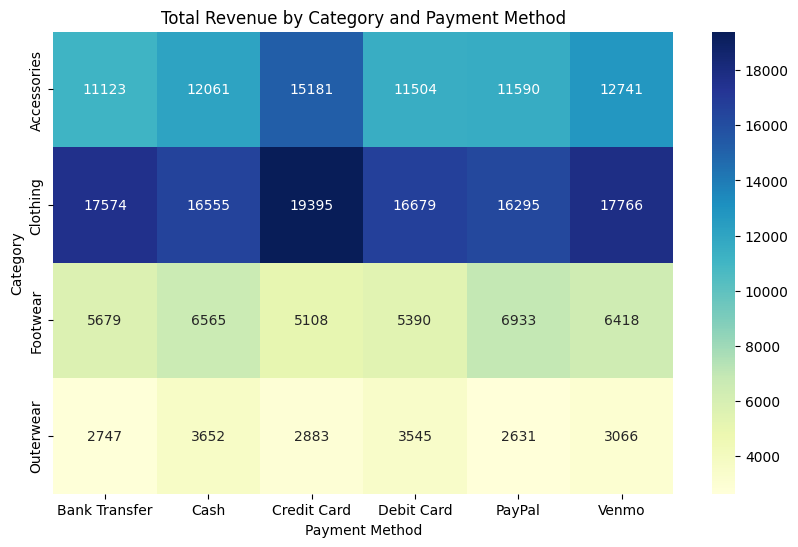

In [ ]:
# Візуалізація зведеної таблиці revenue за категоріями товарів та способами оплати
plt.figure(figsize=(10,6))
sns.heatmap(pivot_category_payment,
            annot=True,
            fmt='.0f',
            cmap='YlGnBu')
plt.title('Total Revenue by Category and Payment Method')
plt.ylabel('Category')
plt.xlabel('Payment Method')
plt.show()

**💡 Висновки:**
1. 👕 Домінування категорії Clothing:

Категорія «Одяг» є безумовним лідером за обсягом виручки в усіх каналах оплати.

Найбільший грошовий потік генерується через Credit Card (19,395 USD) та Venmo  📱 (17,766 USD). Це вказує на високу оборотність товарів цієї групи та лояльність покупців до цифрових методів оплати в цьому сегменті.

2. 💳 Аналіз платіжної поведінки:

Кредитні картки — найбільш пріоритетний метод оплати для дорогих категорій (Clothing, Accessories).
Cash та PayPal демонструють стабільно високі показники в категорії Footwear, що може свідчити про специфіку офлайн-продажів або регіональні особливості розрахунків за взуття.
⚠️ Низька популярність Bank Transfer: Цей метод демонструє найнижчі показники в більшості категорій (зокрема, в Outerwear — 2,747 USD), що підкреслює тренд на миттєві платежі.

3. 🧥 Потенціал росту (Outerwear):

Категорія «Верхній одяг» показує найнижчі результати продажів. Це може бути зумовлено сезонністю або недостатнім асортиментом. Найвищий показник тут у Cash (3,652 USD), що не характерно для інших категорій і потребує додаткового дослідження (можливо, це продажі через фізичні точки/шоуруми).


**🎯 Рекомендації:**

- 💳 Оптимізація еквайрингу: фокусуватися на покращенні досвіду оплати через Credit Card та Venmo, оскільки вони приносять найбільший чек.

- 📈 Маркетинговий фокус: розглянути можливість стимулювання продажів Outerwear та Footwear через таргетовані акції при оплаті цифровими гаманцями (PayPal/Venmo) для вирівнювання структури доходів.


###**8. 🎟️ Аналіз впливу промоакцій на фінансові показники**

In [ ]:
# Аналіз доходу та поведінки клієнтів залежно від застосування знижки

pivot_discount_category = df.pivot_table(
    index='Category',
    columns='Discount Applied',
    values='Purchase Amount (USD)',
    aggfunc='sum',
    fill_value=0
)
pivot_discount_category

Discount Applied,No,Yes
Category,,
Accessories,42440,31760
Clothing,60585,43679
Footwear,20087,16006
Outerwear,10558,7966


In [ ]:
plot_data = pivot_discount_category.reset_index().melt(
    id_vars='Category',
    var_name='Discount Applied',
    value_name='Total Revenue'
)

fig = px.bar(
    plot_data,
    x='Category',
    y='Total Revenue',
    color='Discount Applied',
    barmode='group',
    title='Загальний дохід за категоріями: зі знижкою та без',
    labels={'Total Revenue': 'Загальна сума (USD)', 'Category': 'Категорія', 'Discount Applied': 'Знижка'},
    color_discrete_sequence=['#E74C3C', '#2ECC71']
)

fig.update_layout(
    title_x=0.5,
    legend_title_text='Застосовано знижку',
    height=500,
    xaxis_title="Категорія товару",
    yaxis_title="Загальна сума (USD)"
)

fig.update_traces(texttemplate='%{y:.3s}', textposition='outside')

fig.show()


**💡 Висновки:**
- 💰 Домінування Full-price продажів:
 більша частина доходу в усіх категоріях надходить від продажів без знижок. Найбільший розрив — у категорії Clothing (\$60.6k  vs \$43.7k).

- 📉 Низька еластичність попиту: застосування знижок не компенсує падіння виручки за рахунок обсягу. Це вказує на те, що знижки наразі знижують маржинальність, а не стимулюють значний ріст продажів.

- 👕 Clothing — ключовий драйвер:
 категорія «Одяг» генерує максимальний дохід незалежно від дисконту, тоді як ⚠️ Outerwear залишається аутсайдером.

**🎯 Рекомендації:**

 Оптимізувати промо-акції для Clothing та Accessories, оскільки клієнти демонструють готовність купувати ці товари за повною ціною.

###**9. 🎨 Які кольори товарів найбільш та найменш популярні в кожній категорії? (Допомагає в управлінні залишками на складі).**

In [ ]:
# Найбільш популярні кольори  в кожній категорії
color_stats = df.groupby(['Category', 'Color']).size().reset_index(name='Sales Count')
top_colors = color_stats.sort_values(['Category', 'Sales Count'], ascending=[True, False]).groupby('Category').head(3)
styled_table = top_colors.style.background_gradient(subset=['Sales Count'], cmap='YlGn') \
    .set_properties(**{'text-align': 'center', 'border': '1px solid white'}) \
    .set_caption("🔥 ТОП-3 кольори по кожній категорії товарів") \
    .hide(axis='index')


styled_table

Category,Color,Sales Count
Accessories,Olive,66
Accessories,Blue,59
Accessories,Gray,59
Clothing,Teal,84
Clothing,Maroon,83
Clothing,Black,81
Footwear,Olive,31
Footwear,Violet,30
Footwear,Yellow,30
Outerwear,Blue,19


**💡 Висновки:**

👕 Одяг (Clothing) — найпопулярніша категорія з високими показниками продажів. Лідирують глибокі та класичні кольори: Teal (морська хвиля), Maroon (бордовий) та Black (чорний).


👜 Аксесуари (Accessories) — тут клієнти віддають перевагу спокійним відтінкам: Olive (оливковий), Blue (синій) та Gray (сірий).


🌿 Оливковий колір (Olive) є універсальним хітом, оскільки він потрапив у ТОП одразу в трьох категоріях: Аксесуари, Взуття та Верхній одяг.

**🎯 Рекомендації:**

🔹 Пріоритет закупівлі: кольори Teal та Maroon в категорії одягу мають найвищий попит (84 та 83 продажі). Переконайтеся, що ці позиції завжди є в наявності.

🔹 Розширення лінійки: оскільки Olive популярний скрізь, варто розглянути можливість додавання цього кольору в категорію Clothing, якщо його там ще немає.

🔹  Оптимізація Footwear та Outerwear: у цих категоріях продажі значно нижчі. Можливо, варто зменшити загальний обсяг замовлень, але зосередитися саме на вказаних топових кольорах, щоб уникнути залишків.

In [ ]:
# Найменш популярні кольори в кожній категорії
color_stats = df.groupby(['Category', 'Color']).size().reset_index(name='Sales Count')

worst_colors = color_stats.sort_values(['Category', 'Sales Count'], ascending=[True, False]).groupby('Category').tail(3)

styled_worst = worst_colors.style.background_gradient(subset=['Sales Count'], cmap='Reds_r') \
    .set_caption("⚠️ ТОП найменш популярних кольорів по категоріях") \
    .hide(axis='index')

styled_worst


Category,Color,Sales Count
Accessories,White,41
Accessories,Purple,40
Accessories,Pink,39
Clothing,Indigo,59
Clothing,Magenta,59
Clothing,Blue,49
Footwear,White,17
Footwear,Red,16
Footwear,Charcoal,15
Outerwear,Maroon,8


**💡 Висновки:**

Outerwear (найгірші показники): Maroon🔴, Orange🟠 та Peach🍑 мають лише по 8 продажів. Ці яскраві та специфічні кольори для верхнього одягу є найменш затребуваними😕.

**🎯 Рекомендації**:

- 📦 Скорочення асортименту: рекомендується вивести з постійного замовлення кольори Maroon, Orange та Peach для категорії Outerwear, щоб звільнити місце для більш ходових позицій (наприклад, Olive, який був лідером).

- 💸 Розпродаж (Clearance): для кольорів із продажами менше 20 (Footwear та Outerwear) варто запустити акцію -50%, щоб максимально швидко розпродати залишки та перетворити їх на обігові кошти.

# 🔬 Тестування гіпотез


####**1. Вплив наявності знижки (Discount Applied) на суму покупки (Purchase Amount)**

 Формулюємо гіпотез:

- Нульова гіпотеза (Но
)
: Знижка не впливає на суму покупки (середні значення однакові).

- Альтернативна гіпотеза (Н1
): Сума покупки зі знижкою та без неї суттєво відрізняється.


In [ ]:
from scipy import stats

# 1. Розділяємо дані на дві групи
group_with_discount = df[df['Discount Applied'] == 'Yes']['Purchase Amount (USD)']
group_no_discount = df[df['Discount Applied'] == 'No']['Purchase Amount (USD)']

# 2. Проводимо Т-тест (для незалежних вибірок)
t_stat, p_val = stats.ttest_ind(group_with_discount, group_no_discount)

print(f"T-статистика: {t_stat:.4f}")
print(f"P-значення (p-value): {p_val:.4f}")

# 3. Інтерпретація результату
alpha = 0.05
if p_val < alpha:
    print("Висновок: Знижка має статистично значущий вплив на суму покупки.")
else:
    print("Висновок: Статистично значущої різниці не виявлено (вплив знижки випадковий).")


T-статистика: -1.1114
P-значення (p-value): 0.2665
Висновок: Статистично значущої різниці не виявлено (вплив знижки випадковий).


**💡 Висновки:**

Наявність знижки не має статистично значущого впливу на суму покупки. Тобто різниця в середніх чеках між групами "зі знижкою" та "без" **є випадковою**.

**🎯 Рекомендації:**

- Знижка не стимулює клієнтів купувати на більші суми.
- Можливо, знижка просто зменшує прибуток з кожного товару, не збільшуючи при цьому обсяг кошика.

- Потрібно переглянути стратегію дисконтування: або змінити розмір знижки, або умови її надання (наприклад, "знижка при покупці від 100$").

####**2. Хі-квадрат тест: чи залежить вибір Категорії (Category) від Статі (Gender)?**

Формулювання гіпотез:

- Нульова гіпотеза (Ho
): Стать клієнта (Gender) та категорія товарів (Category) не залежать одне від одного. Розподіл покупок за категоріями однаковий як для чоловіків, так і для жінок.

- Альтернативна гіпотеза (H1
): Існує статистично значущий зв'язок між статтю та категорією товарів. Вибір певної категорії залежить від того, хто здійснює покупку.

In [ ]:
from scipy.stats import chi2_contingency

# 1. Створюємо таблицю спряженості (підрахунок кількості для кожної пари Gender/Category)
contingency_table = pd.crosstab(df['Gender'], df['Category'])
print("Таблиця спряженості:")
print(contingency_table)
print("-" * 30)

# 2. Проводимо Хі-квадрат тест
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Хі-квадрат статистика: {chi2:.4f}")
print(f"P-значення (p-value): {p:.4f}")


alpha = 0.05
if p < alpha:
    print("\nВисновок: Існує статистично значуща залежність між статтю та категорією товарів.")
    print("Вибір категорії залежить від статі клієнта.")
else:
    print("\nВисновок: Залежності не виявлено.")
    print("Стать не впливає на вибір категорії товарів (вибір розподілений випадково).")


Таблиця спряженості:
Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
Female            392       556       199        101
Male              848      1181       400        223
------------------------------
Хі-квадрат статистика: 0.5984
P-значення (p-value): 0.8968

Висновок: Залежності не виявлено.
Стать не впливає на вибір категорії товарів (вибір розподілений випадково).


**💡 Висновки:**

Результат p-value = 0.8968 є дуже високим (значно більшим за критичні 0.05). Це означає, що структура покупок у чоловіків та жінок майже ідентична.
Тест показує, що стать клієнта не змінює ймовірність купівлі конкретного типу товару. Вибір категорії є гомогенним (однаковим) для обох статей.

**🎯 Рекомендації:**

Рекомендується маркетинговому відділу не розділяти рекламні кампанії за статтю для цих категорій — один і той самий підхід працюватиме однаково добре і для чоловіків, і для жінок.


# 🏁 Висновки та рекомендації

**Головні висновки:**

1. **💎 Ядро прибутку:** найбільший дохід приносять чоловіки 56–70 років, які купують одяг (Blouse, Shirt) у класичних кольорах, переважно восени.
Марна трата маржі: Статистичні тести підтвердили, що знижки та стать клієнта не впливають на суму чека або вибір категорії — люди купують те саме і за ту ж ціну.
2. **📍 Географічний розрив:** Монтана та Каліфорнія є лідерами продажів 📈, тоді як величезний ринок Флориди демонструє аномально низьку ефективність 📉 (на 70% менше лідерів).
3. **⚠️ Проблема сервісу:** дорога експрес-доставка (Next Day Air) для верхнього одягу має найнижчий рейтинг (3.20), що вказує на серйозні логістичні збої.
4. **🧥 Неліквідні залишки:** специфічні кольори (Orange, Peach) у верхньому одязі майже не продаються, заморожуючи обігові кошти компанії.

**Ключові рекомендації:**

1. **🎯 Зміна промо-політики:** скасуйте прямі знижки на користь акцій "від суми чека" (наприклад, -15% при покупці від $100), щоб реально стимулювати ріст кошика.
2. **🤝 Уніфікація маркетингу**: використовуйте єдині рекламні кампанії для чоловіків та жінок, оскільки їхні вподобання в категоріях ідентичні (p-value = 0.89).
3. **🧹 Очищення складу:** проведіть агресивний розпродаж (-50%) яскравих кольорів верхнього одягу та замініть їх у закупівлі на універсальний колір Olive.
4. **🔍 Аудит логістики:** терміново перевірте якість доставки Next Day Air або тимчасово відмовтеся від неї, щоб зупинити відтік розчарованих клієнтів.
5. **🗺️ Регіональна стратегія:** проаналізуйте асортимент у Флориді та Канзасі на відповідність клімату та перенесіть успішні маркетингові практики з Монтани на сусідні штати.

